# Branch Testing
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. MOT Master Control

In [70]:
from pytweezer.experiment.motmaster_client import MotMasterClient
exp = MotMasterClient()

In [71]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(10)
#exp.start_motmaster_experiment()

{'ok': True,
 'command': 'interface_method',
 'method': 'set_iterations',
 'state': 'accepted'}

## 2. Hamamatsu Camera

In [57]:
from pytweezer.drivers.imagemX2 import ImagEMX2Camera

hamcam : ImagEMX2Camera = ImagEMX2Camera()

In [58]:
hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 0, 0, 512, 512
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## 3. Phasemask Generation

In [87]:
import pytweezer.phasemask as pm

dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

W1 = np.ones((5, 5))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
--- Target Generation ---
Grid: 5x5
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.04e-04 | Uniformity: 72.66% | Min/Max ratio: 0.327
Iteration 010 | Mean-Squared Error: 6.17e-07 | Uniformity: 91.19% | Min/Max ratio: 0.712
Iteration 020 | Mean-Squared Error: 1.38e-07 | Uniformity: 91.93% | Min/Max ratio: 0.740
Iteration 030 | Mean-Squared Error: 1.08e-07 | Uniformity: 92.07% | Min/Max ratio: 0.744
Iteration 040 | Mean-Squared Error: 4.79e-08 | Uniformity: 92.04% | Min/Max ratio: 0.745
Iteration 050 | Mean-Squared Error: 6.89e-08 | Uniformity: 92.09% | Min/Max ratio: 0.746
Iteration 060 | Mean-Squared Erro

## 4. SLM

In [14]:
from pytweezer.drivers.slm import SLM

slm : SLM = SLM()

2026-07-31 12:13:45 | INFO     | PH-BEAST | slm | SLM board 1: 1024x1024 @ 8-bit, serial 7752, 40.200 degC
2026-07-31 12:13:45 | INFO     | PH-BEAST | slm | Loaded LUT C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT


In [88]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## 5. Analysis Functions

In [17]:
import pytweezer.analysis.analysis as pyt

texp = pyt.TweezerExperimentAnalysis(day='26',month='05May', year='2026')

---- 26/05May/202026 Tweezer Experiment Analysis Initialised ----


## 5. Test Experiment Run

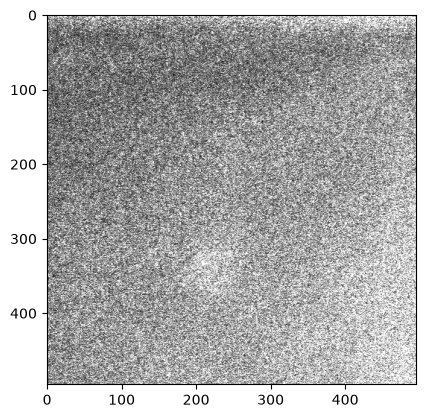

In [98]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment()

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1 = imgs[::2]
imgs2 = imgs[1::2]
img_mean = imgs1.mean(axis=0)
plt.imshow(img_mean, cmap='gray', vmax=img_mean.max()*0.6)

In [99]:
hamcam.close()

In [100]:
slm.close()